# Atari - BreakOut

## Imports

In [1]:
import os
import sys
import warnings
from functools import partial

In [2]:
import torch
from torch import nn
from tensordict import TensorDict
from tensordict.nn import TensorDictModule
from torchrl.envs import GymWrapper
from torchrl.modules import QValueActor, EGreedyModule, DuelingCnnDQNet, NoisyLinear
from torchrl.data.replay_buffers import LazyMemmapStorage, PrioritizedReplayBuffer
from torchrl.record import CSVLogger

In [3]:
from typing import Callable, Optional

In [4]:
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
from stable_baselines3.common.atari_wrappers import FireResetEnv, EpisodicLifeEnv, ClipRewardEnv

In [5]:
warnings.filterwarnings("ignore")
gym.register_envs(ale_py)
if os.path.abspath("package") not in sys.path: sys.path.append(os.path.abspath("package"))

In [6]:
from package.environment import GymPreprocessing, create_breakout_env
from package.dqn_types import ModelParameters, PathsParameters, EnvSpaceName
from package.utils import fill_buffer, init_collector
from package.video import VideoPlayer, Recorder, unstack_frames
from package.Logger import SmartLogger, LogsConfig
from package.modules import (Model,
                             Scale,
                             Optimizer,
                             Trainer,
                             initialize_weights,
                             init_lazy_layers,
                             n_parameters)

**In this version we use torchrl API to train a DQN agent on the Atari game `Breakout`.**

## Setup Environment.

**For wrapping `gym.Env` we use torchrl `Gym Wrapper`.**<br>
**The returned value of the environment variable is `uint8`, this will save a lot of memory for further storage.**<br>
**Note: all data is stored on `CPU`, and transfered to `MPS` or `GPU` only when needed.
The reason for this is that I had some issues with `MPS` and `GPU` memory management then working with torchrl API.**

## Hyperparameters

**To avoid problems with namespace overflow we will use special variables with hyperparameters.**

In [7]:
model_space: ModelParameters = ModelParameters(batch_size=64, lr=2e-4, min_lr=1e-8, max_grad_norm=10.)
paths_space: PathsParameters = PathsParameters(exp_name="experience", log_dir="breakout_logs")
names_space: EnvSpaceName = EnvSpaceName()

In [8]:
print(model_space)
print(paths_space)
print(names_space)

ModelParameters(lr=0.0002, min_lr=1e-08, max_grad_norm=10.0, batch_size=128, trg_update_freq=1000, rb_expansion=10, dev=device(type='mps', index=0), cpu=device(type='cpu', index=0))
PathsParameters(exp_name='experience', log_dir='breakout_logs', storage_path='breakout_logs/dump/storage')
EnvSpaceName(actor='actor', explorer='explorer', action='action', observation='observation', reward='reward', terminated='terminated', truncated='truncated', done='done', next='next', loss='loss', td_error='td_error', index='index')


**For logging results will and custom-made `Logger`.**

Visually, one can observe that the "trail" of frames makes it difficult to assess exactly where the ball is heading. <br>
For the algorithm to see the direction of the ball, the residual movement should be less saturated (pixels should be darker). <br>
In practice, things are not straightforward. The ball can occupy several pixels at any given moment. <br>
Sometimes the pixels are indeed darker, and sometimes all pixels of the ball are equal or take close values chaotically. <br>
As a result, the model may frequently change its "opinion" about the ball's movement, failing to find an optimal game strategy.

This assessment was formed after observing the results of a trained DQN (CNN) model. <br>
The model would drive the controlled "paddle" into the corner of the screen, <br>
occasionally twitching in different directions but immediately returning to the corner. <br>
After visual analysis, I hypothesized that the model was getting stuck in the corner due to incorrect motion direction detection. <br>
Occasionally, "enlightenment" would occur, and the model would move towards the ball, <br>
but then lose its direction again on the next prediction and return to the corner.

To visually observe the ball's movement, I recommend using "plotly" <br>
due to the interactive capabilities of the created objects. <br>
One of these features allows checking pixel brightness without writing additional code.

In [9]:
def explore_statistics(tensordict: TensorDict, key: str) -> dict[str, float]:
    """
    Calculates basic statistics (mean, std, min, max) for a specific tensor in a TensorDict.

    Args:
        tensordict: The TensorDict to analyze.
        key: The key of the tensor is to calculate statistics for.

    Returns:
        A dictionary containing the calculated statistics.
    """
    mean: float = tensordict[key].float().mean().item()
    std: float = tensordict[key].float().std().item()
    min_value: float = tensordict[key].float().min().item()
    max_value: float = tensordict[key].float().max().item()
    return dict(mean=mean, std=std, min=min_value, max=max_value)

In [10]:
# Будем применять Reward Clipping в обучении агента.
# Но зачем ?
# 1. Стабильность градиентов:
# В Breakout награды за кирпичи растут по мере прохождения уровней
# или в зависимости от ряда (например, нижние ряды — 1 очко, верхние — 7 очков).
# Если агент внезапно получает 7 очков вместо 1, ошибка временной разности (TD-error) резко возрастает.
# Это приводит к огромным обновлениям весов нейросети,
# что может «выбить» агента из стабильного состояния и разрушить уже выученную стратегию.
#
# 2. Проблема функции ценности (V или Q):
# Алгоритмы оценивают ожидаемую сумму будущих наград. Если награды не масштабированы,
# итоговые значения Q(s, a) могут исчисляться сотнями. Оптимизаторам (типа Adam) гораздо проще работать,
# когда значения находятся в небольшом диапазоне (например, от -1 до 1 или около 0).
#
# Почему Clipping а не Scale ?
# Идеальная стабильность. Агент просто знает: «попасть в кирпич — это хорошо».

In [11]:
# Нужен ли PenaltyLoss?
# Почему это поможет?
# Агент живет в мире «бесплатного риска». Если он пропустит мяч, он просто перестает получать очки.
# Для него это «ноль». Но в начале обучения он и так почти всегда получает «ноль», потому что не умеет попадать по мячу.
# Отрицательная награда создает контраст:
# • Попал по мячу/разбил кирпич: +1 (хорошо).
# • Пропустил мяч: -1 (очень плохо).
#
# Это заставляет агента гораздо быстрее выучить базовое правило: «нужно держать ракетку под мячом»,
# прежде чем он вообще начнет осознанно целиться в кирпичи.

# Но есть сложности реализации. Если штраф слишком большой, агент может стать «пессимистом».
# В некоторых играх это приводит к тому, что агент предпочитает совершить «суицид» как можно быстрее,
# чтобы прекратить эпизод и больше не получать мелкие штрафы за время.
#
# Чтобы не эксперементировать с разными значениям "penalty", можно использовать более простой трюк - «Конец эпизода при потере жизни».
# Результат: Для агента «смерть» (потеря жизни) эквивалентна потере всех будущих очков, которые он мог бы заработать.
# Это самый мощный сигнал для сходимости, при этом вам не нужно подбирать «вес» отрицательной награды.

In [12]:
env_prep = GymPreprocessing(
    partial(AtariPreprocessing, noop_max=0, frame_skip=1, terminal_on_life_loss=False, screen_size=84),
    partial(EpisodicLifeEnv),
    partial(FireResetEnv),
    partial(ClipRewardEnv),
    partial(FrameStackObservation, stack_size=4)
)

In [13]:
build_env: Callable[[], GymWrapper] = lambda: create_breakout_env(transform=env_prep)
envir: GymWrapper = build_env()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [14]:
logs_config: LogsConfig = LogsConfig(
    paths_space.log_dir, metrics_save_freq=5, weights_save_freq=10, videos_save_freq=10
)
logger: SmartLogger = SmartLogger(names_space.actor, options=logs_config, exp_name=paths_space.exp_name)

## Evaluation & Visual Analysis
**Before training, we can visualize the agent's initial performance and analyze the observation data.**

In [15]:
exp: TensorDict = envir.rollout(max_steps=400, auto_reset=True, break_when_any_done=False)
print(f"Observation shape: {exp[names_space.observation].shape}")
print(f"Observation statistics: {explore_statistics(exp, names_space.observation)}")

Observation shape: torch.Size([400, 4, 84, 84])
Observation statistics: {'mean': 41.45713806152344, 'std': 60.23131561279297, 'min': 0.0, 'max': 148.0}


In [16]:
# Experience TensorDict have duplicated observation state.
# For env0 we choose some action and got env1,
# after that we choose some action for state env1 and got state env2,
# and so on...
assert torch.all(exp[names_space.next][names_space.observation][0] == exp[names_space.observation][1])

In [17]:
demo: bool = False
if demo:
    player = VideoPlayer(unstack_frames(exp, flip=True), fps=10, title="Atari Agent Preview")
    player.show(width=400, height=500)
del exp

**Data is not normalized before being fed to the model because we intend to store the "Buffer" as a "MemMap" object. <br>To reduce the buffer size, it is preferable to store images in "uint8" format.**

## Dueling DQN Configuration
**TorchRL provides implementations of Dueling CNN DQN. In this project, we utilize `EGreedyModule` for action exploration during environment interaction.**

In [18]:
out_features = envir.action_spec.shape.numel()
cnn_kwargs = dict(num_cells=(64, 128, 256), kernel_sizes=(8, 4, 3), strides=(4, 2, 1))
mlp_kwargs = dict(num_cells=256, layer_class=NoisyLinear)

In [19]:
model: TensorDictModule = Model(
    actor=QValueActor(nn.Sequential(
        Scale(value=255.),
        DuelingCnnDQNet(out_features=out_features, cnn_kwargs=cnn_kwargs, mlp_kwargs=mlp_kwargs)
    ),
        in_keys=[names_space.observation],
        spec=envir.action_spec),
    # Turn off explorer, because we use "NoisyLinear".
    explorer=EGreedyModule(envir.action_spec, 0.0, 0.0, annealing_num_steps=0)
)

## Weights Initialization
**Proper weight initialization is essential for deep reinforcement learning stability. We define a custom initialization function for various layer types.**

In [20]:
model: TensorDictModule = init_lazy_layers(envir.reset(), model).apply(initialize_weights)
last_upd: Optional[str] = logger.get_last_update(names_space.actor)
model.load_state_dict(torch.load(last_upd)) if last_upd else None

<All keys matched successfully>

In [22]:
print(f"Weights counts: {n_parameters(model)}")

Weights counts: 13291466


## Prioritized Replay Buffer & Collector.

**The classic Replay Buffer is not as efficient for training because sampling does not take into account the contribution of each individual record.** <br>
**Prioritized Replay Buffer compensates for this deficiency.
By adding new records to the buffer, we will also update the priority values of the remaining records based on the error received.
The higher the rating, the higher the priority. This way, sampling of records with a large error will occur more often.
The sampling algorithm is based on SumTree.**

**Records will be buffered and written to a dedicated directory.** <br>
**The size of the dedicated directory after the buffer is completely full will be over 200 GB.** <br>
**It is for this reason that the environment data is supplied in `uint8`.**

**Buffer will be automatically cleaned up after ending the session.**

In [23]:
buffer = PrioritizedReplayBuffer(
    alpha=0.7,
    beta=0.9,
    batch_size=model_space.batch_size,
    storage=LazyMemmapStorage(
        max_size=5 * 10 ** 5,
        scratch_dir=paths_space.storage_path,
        existsok=True,
        auto_cleanup=True
    )
)

## Memory & Experience Collection
**Efficient experience storage is crucial for RL. We use a Prioritized Replay Buffer with memory-mapped storage to handle large datasets.**

In [24]:
collector_kwargs = dict(
    frames_per_batch=200,
    total_frames=-1,
    extend_buffer=False,
    storing_device=model_space.cpu,
    policy_device=model_space.dev
)

In [25]:
fill_buffer(init_collector(build_env, **collector_kwargs), buffer, 1000, show=True)

  0%|          | 0/5 [00:00<?, ?it/s]

2026-03-30 18:46:04,617 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([500000]) shape [END]


100%|██████████| 5/5 [00:02<00:00,  2.07it/s]


## Agent Configuration & Initialization
**Configure the collector and recording utilities, then initialize the optimizer and trainer.**

In [26]:
collector_kwargs = dict(
    frames_per_batch=model_space.batch_size,
    total_frames=-1,
    extend_buffer=False,
    storing_device=model_space.cpu,
    policy_device=model_space.dev
)

In [27]:
video_maker = Recorder(
    CSVLogger(paths_space.exp_name, paths_space.log_dir, video_format="mp4", video_fps=30),
    build_env(),
    deterministic=True
)
collector = init_collector(build_env, model, **collector_kwargs)
optim_method = Optimizer(network=model.to(model_space.dev), action_space=envir.action_spec, params=model_space)

In [28]:
optim_method

[0.0002]

**"video_maker" will shoot video of agent game session and save in log directory.**

## Training Loop & Optimization

**Torchrl has an API for model training. <br>
However, this API currently has several compatibility issues with other classes. <br>
Therefore, we're implementing our own functionality.**

**The custom Trainer class manages the training process, integrating the model, optimizer, and logging utilities.**

In [29]:
trainer = Trainer(model, optim_method, model_space, names_space, logger, video_maker)

In [57]:
trainer.train(n_epochs=1, rb=buffer, loader=collector)

Loss: 0.00463; Mean_reward: 0.00000; Grad_norm: 0.14756; Weights_norm: 46.58265; Lr: 0.00020: 100%|██████████| 1/1 [00:00<00:00,  1.47it/s]


**Note: The Logger uses the term "Epoch" to refer to the training step index.**

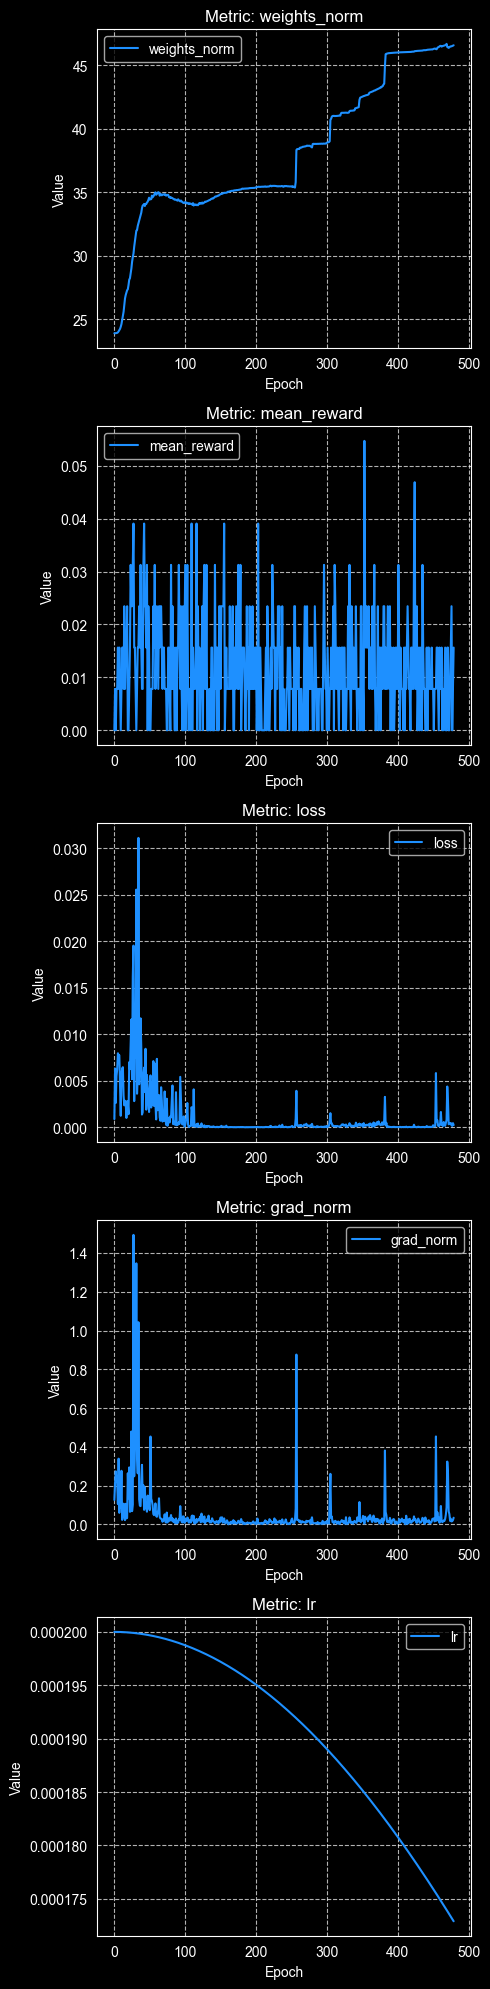

In [58]:
logger.draw_scalars()